<a href="https://colab.research.google.com/github/chenyicheng2008/pydata-book/blob/1st-edition/semichemical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import yfinance as yf
import pandas as pd

# Define the ticker symbols
ticker_symbols = ['amat','lrcx','klac','asml','TER',
                  '8035.T','6146.T', '4063.T', '6857.T', '7751.T', '4186.T',
                    '6920.T', '7735.T','4626.T','4971.T','3110.T','6961.T','6941.T',
                  '2345.TW','4772.TWO','4749.TWO',
                  '2467.TW', '6196.TW', '5234.TW', '3413.TW','4755.TW', '4768.TWO','4770.TW', '1773.TW',
                  '3131.TWO','3680.TWO',
                  '3587.TWO','3583.TW'] #'NVDA', 'TSLA', 'AVGO','MSFT', 'AAPL', 'MSFT', 'GOOGL', 'AMZN',

# Create an empty DataFrame to store the retrieved information
df = pd.DataFrame()

# Iterate over each ticker symbol
for ticker_symbol in ticker_symbols:
    # Create a ticker object for the specified symbol
    ticker = yf.Ticker(ticker_symbol)

    # Get the information dictionary
    ticker_info = ticker.info

    # Define the desired information keys
    keys = ['shortName', 'country','currentPrice', 'marketCap','trailingEps',
        'forwardEps','trailingPE', 'forwardPE', 'earningsGrowth','grossMargins', '52WeekChange',
        'industry','longBusinessSummary']  #'pegRatio',

    # Create a dictionary to store the retrieved information
    data = {}

    # Extract the desired information from the information dictionary
    for key in keys:
        data[key] = ticker_info.get(key, None)

    # Create a DataFrame from the dictionary
    temp_df = pd.DataFrame(data, index=[ticker_symbol])

    #temp_df['epsGrowth NextYear'] = temp_df['forwardPE'] / temp_df['pegRatio']
    temp_df['EPS Growth']=temp_df['earningsGrowth']*100
    temp_df[ 'marketCap']=temp_df[ 'marketCap']/1000000000

    #temp_df['EPS Growth(F)']=temp_df['epsGrowth NextYear']#.map('{:.0f}%'.format)
    temp_df['EPS Growth']=temp_df['EPS Growth'] #.map('{:.0f}%'.format)

    #temp_df['EPS Growth(F)']=temp_df['EPS Growth(F)'].round(2)
    temp_df['EPS Growth_F']=temp_df['trailingPE']/temp_df['forwardPE']-1


    temp_df['52WeekChange']=temp_df['52WeekChange']*100
    #temp_df['52WeekChange']=temp_df['52WeekChange'].map('{:.0f}%'.format)
    #temp_df['grossMargins']=temp_df['grossMargins']*100
    #temp_df['grossMargins']=temp_df['grossMargins'].map('{:.0f}%'.format)

    temp_df['forwardPE']=temp_df['forwardPE']#.round(2)
    # Append the DataFrame to the main DataFrame
    df = pd.concat([df, temp_df])

# Display the DataFrame
df['forwardPE']=pd.to_numeric(df['forwardPE'], errors='coerce')
df['trailingPE']=pd.to_numeric(df['trailingPE'], errors='coerce')

df['forwardPE']=df['forwardPE'].round(2)
df['trailingPE']=df['trailingPE'].round(2)
df[ 'marketCap']=df[ 'marketCap'].round(0)
df.fillna('', inplace=True)
df[['shortName', 'country', 'marketCap', 'currentPrice', '52WeekChange', 'trailingEps', 'forwardEps',
       'trailingPE','forwardPE',  'grossMargins', 'EPS Growth' ,'EPS Growth_F',
    '52WeekChange']]




<ipython-input-16-0fb1b1d54000>:57: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

<ipython-input-16-0fb1b1d54000>:57: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

<ipython-input-16-0fb1b1d54000>:57: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

<ipy

,shortName,country,marketCap,currentPrice,52WeekChange,trailingEps,forwardEps,trailingPE,forwardPE,grossMargins,EPS Growth,EPS Growth_F,52WeekChange
amat,"Applied Materials, Inc.",United States,132.0,162.63,8.921039,8.60,9.69,18.91,15.39,0.47408,10.8,0.228841,8.921039
lrcx,Lam Research Corporation,United States,93.0,72.23,-1.200962,3.09,4.27,23.38,17.32,0.47695,28.4,0.349524,-1.200962
klac,KLA Corporation,United States,84.0,630.12,15.313661,21.87,32.82,28.81,19.08,0.59748,29.6,0.510451,15.313661
asml,ASML Holding N.V. - New York Re,Netherlands,278.0,693.08,-1.029575,18.30,26.7,37.87,29.72,0.51147,9.8,0.274224,-1.029575
TER,"Teradyne, Inc.",United States,21.0,125.92,23.961413,3.14,4.25,40.10,29.67,0.57890,14.1,0.351729,23.961413
8035.T,TOKYO ELECTRON,Japan,11127.0,24185.00,0.749838,1013.35,1280.2,23.87,18.89,0.46994,62.0,0.263335,0.749838
6146.T,DISCO CORPORATION,Japan,4630.0,42730.00,27.059174,965.70,1360.94,44.25,31.4,0.69576,47.8,0.409278,27.059174
4063.T,SHIN-ETSU CHEMICAL CO,Japan,10484.0,5296.00,-7.493448,257.39,329.73,20.58,16.06,0.38047,2.9,0.281052,-7.493448
6857.T,ADVANTEST CORP,Japan,6789.0,9198.00,99.306610,142.57,237.73,64.52,38.69,0.54165,171.3,0.667461,99.306610
7751.T,CANON INC,Japan,4872.0,5161.00,40.741754,305.53,362.49,16.89,14.24,0.47603,14.7,0.18643,40.741754


In [2]:
temp_df['trailingPE']/temp_df['forwardPE']-1


,0
3583.TW,0.715939


In [2]:
ticker_info

{'address1': 'No. 208, Ruiguang Road',
 'address2': '11th Floor Neihu District',
 'city': 'Taipei',
 'zip': '11491',
 'country': 'Taiwan',
 'phone': '886 2 8751 2323',
 'fax': '886 2 8751 2020',
 'website': 'https://www.scientech.com.tw',
 'industry': 'Semiconductors',
 'industryKey': 'semiconductors',
 'industryDisp': 'Semiconductors',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Scientech Corporation engages in the research and development, production, sale, and maintenance of process equipment for semiconductors, liquid crystal displays (LCDs), light-emitting diodes (LEDs), and solar power generation industries. The company offers chemical analysis and biotechnology equipment; remote control system; camera lens; flat panel display; mask/reticle and semiconductor front-end process equipment; MEMS/compound semiconductor/LED products; semiconductor packaging and testing equipment; 3D printing equipment; and wet benches/singl

In [17]:
#市值轉美元Trillion
import pandas as pd
import yfinance as yf
from datetime import datetime
from datetime import timedelta
now = datetime.now()
endx = datetime.strftime(now, '%Y-%m-%d')
# Subtract 1 day from the current datetime
one_day_ago = now - timedelta(days=3)

# Format the result as a string
one_day_ago_str = one_day_ago.strftime('%Y-%m-%d')
# Define a function to get exchange rate
def get_exchange_rate(currency):
    ticker = currency + '=X'  # Yahoo Finance ticker for currency exchange rate
    data = yf.download(ticker, start=one_day_ago_str, end=endx)  # Get exchange rate data
    return data['Adj Close'].iloc[-1].iloc[-1]

# Dictionary to map currencies to their respective countries
currency_to_country = { 'Japan':get_exchange_rate('JPY'),'Taiwan':get_exchange_rate('TWD')}

# Convert marketCap to USD for companies in Japan and Taiwan
dfx=df.copy()

for index, row in dfx.iterrows():
    country = row['country']
    if country in ['Japan', 'Taiwan']:

        currency = currency_to_country.get(country) # Extract currency from marketCap

        market_cap_usd = row['marketCap'] / currency  # Convert to USD
        dfx.at[index, 'marketCap_usd'] = market_cap_usd

# Display the updated DataFrame
dfx.loc[:,'marketCap']=df['marketCap'].round(2)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
get_exchange_rate('JPY').iloc[-1]

[*********************100%***********************]  1 of 1 completed


150.02999877929688

In [ ]:
yf.download('JPY=X', start=one_day_ago_str, end=endx)

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-05-10,155.389008,155.886002,155.380997,155.389008,155.389008,0



# Fill missing values in 'marketCap_usd' with corresponding values from 'marketCap'
dfx['marketCap_usd'].fillna(dfx['marketCap'], inplace=True)
dfx['marketCap_usd']=dfx['marketCap_usd'].round(2)
dfx[['shortName', 'country', 'marketCap_usd','industry','longBusinessSummary']]

In [18]:

# Fill missing values in 'marketCap_usd' with corresponding values from 'marketCap'
dfx['marketCap_usd'].fillna(dfx['marketCap'], inplace=True)
dfx['marketCap_usd']=dfx['marketCap_usd'].round(2)
dfx[['shortName', 'country', 'marketCap_usd','industry','longBusinessSummary']]

<ipython-input-18-431e3750c9ba>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,shortName,country,marketCap_usd,industry,longBusinessSummary
amat,"Applied Materials, Inc.",United States,132.00,Semiconductor Equipment & Materials,"Applied Materials, Inc. engages in the provisi..."
lrcx,Lam Research Corporation,United States,93.00,Semiconductor Equipment & Materials,"Lam Research Corporation designs, manufactures..."
klac,KLA Corporation,United States,84.00,Semiconductor Equipment & Materials,"KLA Corporation, together with its subsidiarie..."
asml,ASML Holding N.V. - New York Re,Netherlands,278.00,Semiconductor Equipment & Materials,"ASML Holding N.V. develops, produces, markets,..."
TER,"Teradyne, Inc.",United States,21.00,Semiconductor Equipment & Materials,"Teradyne, Inc. designs, develops, manufactures..."
8035.T,TOKYO ELECTRON,Japan,70.87,Semiconductor Equipment & Materials,"Tokyo Electron Limited, together with its subs..."
6146.T,DISCO CORPORATION,Japan,29.49,Semiconductor Equipment & Materials,Disco Corporation manufactures and sells preci...
4063.T,SHIN-ETSU CHEMICAL CO,Japan,66.78,Chemicals,"Shin-Etsu Chemical Co., Ltd. provides infrastr..."
6857.T,ADVANTEST CORP,Japan,43.24,Semiconductor Equipment & Materials,Advantest Corporation manufactures and sells s...
7751.T,CANON INC,Japan,31.03,Computer Hardware,"Canon Inc., together with its subsidiaries, ma..."


In [19]:
# Convert 'grossMargins' column to numerical values, handling errors
dfx['grossMargins'] = pd.to_numeric(dfx['grossMargins'], errors='coerce')

# Replace empty strings('') or invalid numeric values with NaN
dfx['grossMargins'] = dfx['grossMargins'].replace('', float('nan'))

# Calculate the mean of 'grossMargins' grouped by 'country'
mean_grossMargins = dfx.groupby('country')['grossMargins'].mean()

In [6]:
import pandas as pd
import plotly.express as px



# Group by 'country' and calculate the mean of 'grossMargins'
mean_grossMargins_by_country = dfx.groupby('country')['grossMargins'].mean()
mean_grossMargins = dfx.groupby('country')['grossMargins'].mean()
# Plot bar graph using Plotly
fig = px.bar(mean_grossMargins_by_country, x=mean_grossMargins_by_country.index, y='grossMargins',
             title='半導體材料設備_平均毛利率/國別',
             labels={'country': 'country', 'gross Margins': 'Mean gross Margins'})

# Show the plot
fig.show()


In [8]:
import pandas as pd
import plotly.express as px



# Group by 'country' and calculate the mean of 'grossMargins'
#mean_grossMargins_by_country = dfx.groupby('country')['forwardPE'].mean().reset_index()
dfx['forwardPE'] = pd.to_numeric(dfx['forwardPE'], errors='coerce')
forwordPE_by_country = dfx.groupby('country')['forwardPE'].mean().reset_index()
# Plot bar graph using Plotly
fig = px.bar(forwordPE_by_country, x='country', y='forwardPE',
             title='半導體材料設備_平均PE_forwrd/國別',
             labels={'country': 'country', 'gross Margins': 'Mean gross Margins'})

# Show the plot
fig.show()


In [20]:
# Mapping of old names to new names
name_mapping = {
    'C SUN MANUFACTURING CO': '志聖',
    'MARKETECH INTERNATIONAL CORP': '帆宣',
    'DAXIN MATERIALS CORPORATION': '達興材料',
    'FOXSEMICON INTEGRATED TECHNOLOG': '京鼎',
    'SAN FU CHEMICAL CO LTD': '三福化',
    'INGENTEC': '晶呈科技',
    'ALLIED SUPREME CORP': '上品',
    'SHINY CHEMICAL INDUSTRIAL CO. L': '勝一',
    'GRAND PLASTIC TECHNOLOGY CORP': '弘塑',
    'GUDENG PRECISION INDUSTRIAL CO': '家登',
    'MATERIALS ANALYSIS TECHNOLOGY I': '閎康',
    'SCIENTECH CORPORATION': '辛耘',
    'TSC':'台特化',
    'ecsc':'新應材',
    'ACCTON TECHNOLOGY CORP':'智邦',
}

# Replace values in 'shortName' column with new names
dfx.loc[dfx['shortName'].isin(name_mapping.keys()), 'shortName'] = dfx['shortName'].map(name_mapping)
# Replace empty values in 'forwardPE' with corresponding values from 'trailingPE'
dfx['forwardPE'] = dfx.apply(lambda row: row['trailingPE'] if row['forwardPE'] == '' else row['forwardPE'], axis=1)

In [29]:
# prompt: 找出dfx 內之空白值
# Replace empty strings or values that contain only spaces with NaN
import numpy as np
for column in dfx.columns:
    dfx[column] = dfx[column].replace(r'^\s*$', np.nan, regex=True)
# Find and print rows with missing values in 'dfx'
dfx[(dfx.isnull() ).any(axis=1)]
# prompt: dfx['EPS Growth_F']的中位數

Gf_median = dfx['EPS Growth_F'].median()

dfx.loc["4772.TWO", 'EPS Growth_F'] = Gf_median
dfx.loc["4772.TWO", 'forwardPE'] = dfx.loc["4772.TWO", 'trailingPE']/(1+Gf_median)
dfx.loc["4772.TWO", 'forwardEps'] = dfx.loc["4772.TWO", 'forwardPE']/dfx.loc["4772.TWO", 'currentPrice']
dfx.loc["4749.TWO", 'forwardEps'] = dfx.loc["4749.TWO", 'forwardPE']/dfx.loc["4749.TWO", 'currentPrice']
dfx.loc["2467.TW", 'forwardEps'] = dfx.loc["2467.TW", 'forwardPE']/dfx.loc["2467.TW", 'currentPrice']
dfx.loc["3131.TWO", 'forwardEps'] = dfx.loc["3131.TWO", 'forwardPE']/dfx.loc["3131.TWO", 'currentPrice']

,shortName,country,currentPrice,marketCap,trailingEps,forwardEps,trailingPE,forwardPE,earningsGrowth,grossMargins,52WeekChange,industry,longBusinessSummary,EPS Growth,EPS Growth_F,marketCap_usd


In [30]:
import plotly.express as px

# Assuming 'dfx' contains your DataFrame
import numpy as np
# Replace NaN values in 'forwardPE' with 'trailingPE' values
dfx['forwardPE'].fillna(dfx['trailingPE'], inplace=True)
dfx['marketCap_usd'].fillna(dfx['marketCap'], inplace=True)
# Convert 'marketCap_usd' column to numeric, handling errors
dfx['marketCap_usd'] = pd.to_numeric(dfx['marketCap_usd'], errors='coerce')

# Now, apply the exponentiation and rounding
dfx['marketCap_usdx'] = (dfx['marketCap_usd']**0.7).round(2)

# Plot scatter plot using Plotly Express
fig = px.scatter(dfx, x='forwardPE', y='grossMargins', color='country', size='marketCap_usdx',
                 title='Scatter Plot of Gross Margins vs PE',
                 labels={'forwardPE': 'Forward PE', 'grossMargins': 'Gross Margins', 'country': 'Country'},
                 text='shortName',  # Display 'shortName' on hover
                 hover_name='shortName', hover_data={'marketCap_usd': True},
                 size_max=70)  # Adjust the maximum size of points as needed


# Move legend to the top-left corner of the chart area
fig.update_layout(legend=dict(x=0, y=1, xanchor='left', yanchor='top'))
# Update layout to set height and width
fig.update_layout(height=1000, width=1280)
fig.update_layout(xaxis=dict(range=[3, 60]), yaxis=dict(range=[0.07, 0.73]))
# Add 'shortName' as text on each point with the same color as their corresponding point and at size 10
fig.update_traces( textposition='top center', mode='markers+text', textfont=dict(size=12),showlegend=True)

# Show the plot
fig.show()


<ipython-input-30-78f5949f3dc9>:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-30-78f5949f3dc9>:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

In [32]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go



# Calculate correlation coefficient
corr_coeff = np.corrcoef(dfx['forwardPE'], dfx['grossMargins'])[0, 1]

# Fit a regression line
fit = np.polyfit(dfx['forwardPE'], dfx['grossMargins'], 1)
regression_line = np.poly1d(fit)

# Scatter plot
fig = px.scatter(
    dfx,
    x='forwardPE',
    y='grossMargins',
    color='country',
    size='marketCap_usdx',
    title=f"Scatter Plot of Gross Margins vs Forward PE (r = {corr_coeff:.2f})",
    labels={'forwardPE': 'Forward PE', 'grossMargins': 'Gross Margins', 'country': 'Country'},
    text='shortName',  # Display 'shortName' on hover
    hover_name='shortName',
    hover_data={'marketCap_usdx': True},
    size_max=60  # Adjust the maximum size of points as needed
)

# Add regression line
x_range = np.linspace(dfx['forwardPE'].min(), dfx['forwardPE'].max(), 100)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=regression_line(x_range),
        mode='lines',
        name='Regression Line',
        line=dict(color='red', dash='dash')
    )
)

# Update layout
fig.update_layout(
    legend=dict(x=0, y=1, xanchor='left', yanchor='top'),
    height=800,
    width=1200
)

# Add text annotations for the regression equation
fig.add_annotation(
    x=dfx['forwardPE'].mean(),
    y=dfx['grossMargins'].max(),
    #text=f"y = {fit[0]:.2f}x + {fit[1]:.2f}",
    showarrow=False,
    font=dict(size=12, color="black"),
    align="center",
    xanchor="center",
    yanchor="top"
)

# Display the plot
fig.show()


In [ ]:
fig.write_html("pe.html")


In [35]:
!pip install dash
#To add a regression line and display the correlation coefficient value in the scatter plot chart within the Dash app, you can calculate the regression line and correlation coefficient and then overlay them on the plot. Here's the updated code:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 21.0 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [37]:
import pandas as pd
import numpy as np
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import plotly.graph_objects as go



# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Scatter Plot with Regression Line", style={'textAlign': 'center'}),

    html.Div([
        html.Label("Select X-Axis:"),
        dcc.Dropdown(
            id='x-axis-dropdown',
            options=[{'label': col, 'value': col} for col in dfx.columns],
            value='forwardPE',  # Default value
            clearable=False
        )
    ], style={'width': '30%', 'display': 'inline-block'}),

    html.Div([
        html.Label("Select Y-Axis:"),
        dcc.Dropdown(
            id='y-axis-dropdown',
            options=[{'label': col, 'value': col} for col in dfx.columns],
            value='grossMargins',  # Default value
            clearable=False
        )
    ], style={'width': '30%', 'display': 'inline-block'}),

    dcc.Graph(id='scatter-plot')
])

@app.callback(
    Output('scatter-plot', 'figure'),
    [Input('x-axis-dropdown', 'value'),
     Input('y-axis-dropdown', 'value')]
)
def update_scatter_plot(x_column, y_column):
    # Calculate correlation coefficient
    corr_coeff = np.corrcoef(dfx[x_column], dfx[y_column])[0, 1]

    # Fit a regression line
    fit = np.polyfit(dfx[x_column], dfx[y_column], 1)
    regression_line = np.poly1d(fit)

    # Create scatter plot
    fig = px.scatter(
        dfx,
        x=x_column,
        y=y_column,
        color='country',
        size='marketCap_usdx',
        title=f"Scatter Plot of {y_column} vs {x_column} (r = {corr_coeff:.2f})",
        labels={x_column: x_column, y_column: y_column, 'country': 'Country'},
        text='shortName',  # Display 'shortName' on hover
        hover_name='shortName',
        hover_data={'marketCap_usdx': True},
        size_max=60  # Adjust the maximum size of points as needed
    )

    # Add regression line
    x_range = np.linspace(dfx[x_column].min(), dfx[x_column].max(), 100)
    fig.add_trace(
        go.Scatter(
            x=x_range,
            y=regression_line(x_range),
            mode='lines',
            name='Regression Line',
            line=dict(color='red', dash='dash')
        )
    )

    # Add text annotations for the regression equation
    fig.add_annotation(
        x=dfx[x_column].mean(),
        y=dfx[y_column].max(),
        #text=f"y = {fit[0]:.2f}x + {fit[1]:.2f}",
        showarrow=False,
        font=dict(size=12, color="black"),
        align="center",
        xanchor="center",
        yanchor="top"
    )

    # Update layout
    fig.update_layout(
        legend=dict(x=0, y=1, xanchor='left', yanchor='top'),
        height=900,
        width=1200
    )


    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)


<IPython.core.display.Javascript object>

In [ ]:
# Replace empty values in 'forwardPE' with corresponding values from 'trailingPE'
dfx['forwardPE'] = dfx.apply(lambda row: row['trailingPE'] if row['forwardPE'] == '' else row['forwardPE'], axis=1)

In [71]:
dfx

,shortName,country,currentPrice,marketCap,trailingEps,forwardEps,trailingPE,forwardPE,pegRatio,earningsGrowth,grossMargins,52WeekChange,industry,longBusinessSummary,epsGrowth NextYear,EPS Growth,EPS Growth(F),EPS Growth_F,marketCap_usd,marketCap_usdx
amat,"Applied Materials, Inc.",United States,162.63,132.0,8.60,9.69,18.91,15.39,,0.108,0.47408,8.048856,Semiconductor Equipment & Materials,"Applied Materials, Inc. engages in the provisi...",,10.8,,0.228841,132.00,30.51
lrcx,Lam Research Corporation,United States,72.23,93.0,3.09,4.27,23.38,17.32,,0.284,0.47695,-2.093822,Semiconductor Equipment & Materials,"Lam Research Corporation designs, manufactures...",,28.4,,0.349524,93.00,23.87
klac,KLA Corporation,United States,630.12,84.0,21.87,32.82,28.81,19.08,,0.296,0.59748,14.667296,Semiconductor Equipment & Materials,"KLA Corporation, together with its subsidiarie...",,29.6,,0.510451,84.00,22.23
asml,ASML Holding N.V. - New York Re,Netherlands,693.08,278.0,18.30,26.7,37.87,29.72,,0.098,0.51147,-1.026487,Semiconductor Equipment & Materials,"ASML Holding N.V. develops, produces, markets,...",,9.8,,0.274224,278.00,51.38
TER,"Teradyne, Inc.",United States,125.92,21.0,3.14,4.25,40.10,29.67,,0.141,0.57890,24.520886,Semiconductor Equipment & Materials,"Teradyne, Inc. designs, develops, manufactures...",,14.1,,0.351729,21.00,8.42
8035.T,TOKYO ELECTRON,Japan,24185.00,11127.0,1013.35,1280.2,23.87,18.89,,0.620,0.46994,-4.236788,Semiconductor Equipment & Materials,"Tokyo Electron Limited, together with its subs...",,62.0,,0.263335,70.83,19.73
6146.T,DISCO CORPORATION,Japan,42730.00,4630.0,965.70,1360.94,44.25,31.40,,0.478,0.69576,22.155523,Semiconductor Equipment & Materials,Disco Corporation manufactures and sells preci...,,47.8,,0.409278,29.47,10.68
4063.T,SHIN-ETSU CHEMICAL CO,Japan,5296.00,10484.0,257.39,329.73,20.58,16.06,,0.029,0.38047,-10.495186,Chemicals,"Shin-Etsu Chemical Co., Ltd. provides infrastr...",,2.9,,0.281052,66.73,18.92
6857.T,ADVANTEST CORP,Japan,9198.00,6789.0,142.57,237.73,64.52,38.69,,1.713,0.54165,91.744840,Semiconductor Equipment & Materials,Advantest Corporation manufactures and sells s...,,171.3,,0.667461,43.21,13.96
7751.T,CANON INC,Japan,5161.00,4872.0,305.53,362.49,16.89,14.24,,0.147,0.47603,42.569065,Computer Hardware,"Canon Inc., together with its subsidiaries, ma...",,14.7,,0.18643,31.01,11.07


In [ ]:
dfx

,shortName,country,currentPrice,marketCap,trailingEps,forwardEps,trailingPE,forwardPE,pegRatio,earningsGrowth,grossMargins,52WeekChange,epsGrowth NextYear,EPS Growth,EPS Growth(F),marketCap_usd
amat,"Applied Materials, Inc.",United States,208.610,173.0,8.50,9.54,24.54,21.87,1.71,0.193,0.47,76%,12.787647,19%,13%,173.00
lrcx,Lam Research Corporation,United States,977.085,128.0,25.94,35.79,37.67,27.3,4.42,-0.330,0.46,96%,6.176584,-33%,6%,128.00
klac,KLA Corporation,United States,705.860,95.0,19.75,27.67,35.74,25.51,5.16,-0.379,0.60,90%,4.943786,-38%,5%,95.00
asml,ASML Holding N.V. - New York Re,Netherlands,972.910,384.0,21.58,30.74,45.08,31.65,1.96,0.131,0.51,53%,16.147776,13%,16%,384.00
8035.T,TOKYO ELECTRON,Japan,39330.000,18206.0,763.20,963.18,51.53,40.83,26.85,0.201,0.45,136%,1.5208,20%,2%,120.76
6146.T,DISCO CORPORATION,Japan,54790.000,5936.0,683.18,991.6,80.20,55.25,5.08,-0.030,0.67,259%,10.876798,-3%,11%,39.37
4063.T,SHIN-ETSU CHEMICAL CO,Japan,6874.000,13716.0,266.48,310.25,25.80,22.16,6.98,-0.429,0.39,64%,3.174259,-43%,3%,90.98
6857.T,ADVANTEST CORP,Japan,6546.000,4832.0,105.25,143.1,62.19,45.74,18.92,-0.258,0.51,124%,2.417771,-26%,2%,32.05
7751.T,CANON INC,Japan,4544.000,4489.0,264.24,315.34,17.20,14.41,1.13,-0.023,0.47,57%,12.752073,-2%,13%,29.78
4186.T,TOKYO OHKA KOGYO CO,Japan,4600.000,557.0,99.03,185.14,46.45,24.85,6.62,0.158,0.36,84%,3.753182,16%,4%,3.69


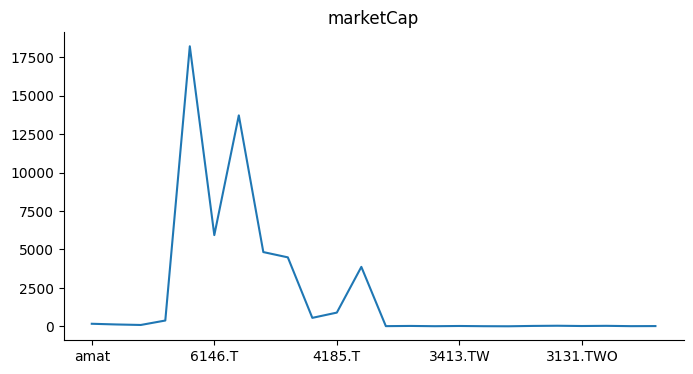

In [ ]:
from matplotlib import pyplot as plt
_df_3['marketCap'].plot(kind='line', figsize=(8, 4), title='marketCap')
plt.gca().spines[['top', 'right']].set_visible(False)

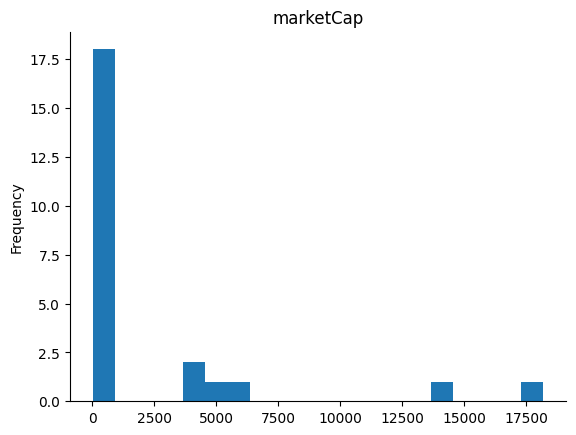

In [ ]:
from matplotlib import pyplot as plt
_df_0['marketCap'].plot(kind='hist', bins=20, title='marketCap')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
market_cap_usd

0.02279852388849378

In [ ]:
data = yf.download("JPY", start=, end=endx)

[*********************100%%**********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['JPY']: Exception("%ticker%: Period 'max' is invalid, must be one of ['1d', '5d']")


In [ ]:
data.

'TWD'

In [ ]:
currency_to_country = { 'Japan':'JPY','Taiwan':  'TWD'}
country.map(currency_to_country)



AttributeError: 'str' object has no attribute 'map'

In [ ]:
exchange_rate

0.0314839668571949